# **Spam**

Initial data shape: (5572, 2)
Classes after label encoding: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}

Class counts before balancing:
label
0    4825
1     747
Name: count, dtype: int64

Class counts after balancing:
label
1    747
0    747
Name: count, dtype: int64


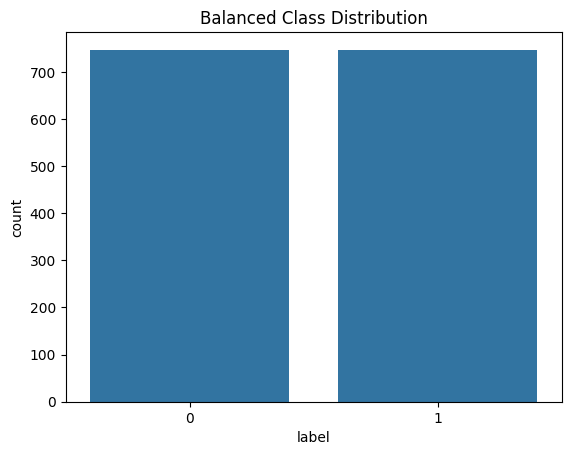


Using device: cuda

STARTING TRAINING WITH DEBERTA MODEL ONLY
Model: microsoft/deberta-v3-base
Optimizer: AdamW, Learning Rate: 2e-5, Batch Size: 32, Epochs: 5

TRAINING WITH SEED = 42
Model: DeBERTa-v3-base (No Quantum, No BiLSTM)
Optimizer: AdamW, Learning Rate: 2e-05, Batch Size: 32, Epochs: 5


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.dense.weight           | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



Model parameters: Total=183,833,090, Trainable=183,833,090
Epoch  1/5 | Train Loss: 0.6031 | Train Acc: 0.6711 | Val Loss: 0.3701 | Val Acc: 0.8440 | Time: 31.79s
Epoch  2/5 | Train Loss: 0.2726 | Train Acc: 0.8932 | Val Loss: 0.3079 | Val Acc: 0.9003 | Time: 32.67s
Epoch  3/5 | Train Loss: 0.1723 | Train Acc: 0.9507 | Val Loss: 0.2493 | Val Acc: 0.9344 | Time: 33.58s
Epoch  4/5 | Train Loss: 0.1064 | Train Acc: 0.9646 | Val Loss: 0.3030 | Val Acc: 0.9344 | Time: 32.76s
Epoch  5/5 | Train Loss: 0.1193 | Train Acc: 0.9679 | Val Loss: 0.3266 | Val Acc: 0.9375 | Time: 33.03s

FINAL RESULTS - SEED 42
Best Validation Accuracy: 0.9375
Final Validation Accuracy: 0.9375
Final Training Accuracy: 0.9679

COMPREHENSIVE METRICS (Best Model)
Accuracy:   0.9331
Precision:  0.9344
Recall:     0.9331
F1-Score:   0.9331
Specificity:0.9067
AUC Score:  0.9709

Per-Class Metrics:
  Not Spam - Precision: 0.9577, Recall: 0.9067, F1: 0.9315
  Spam     - Precision: 0.9108, Recall: 0.9597, F1: 0.9346

Classif

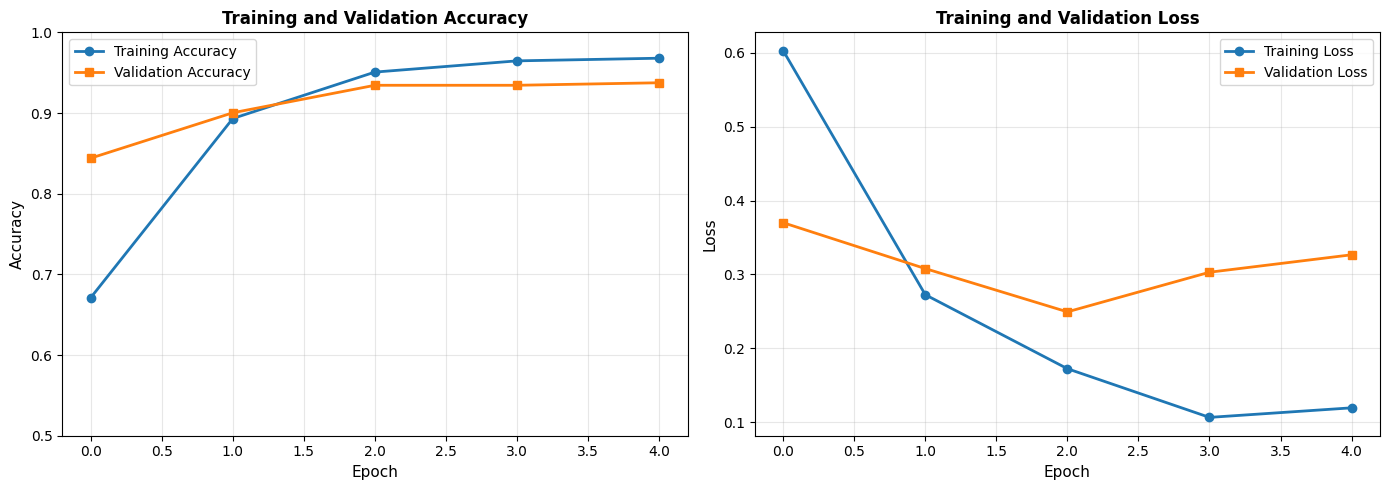

✅ Training curves saved to deberta_training_curves.pdf


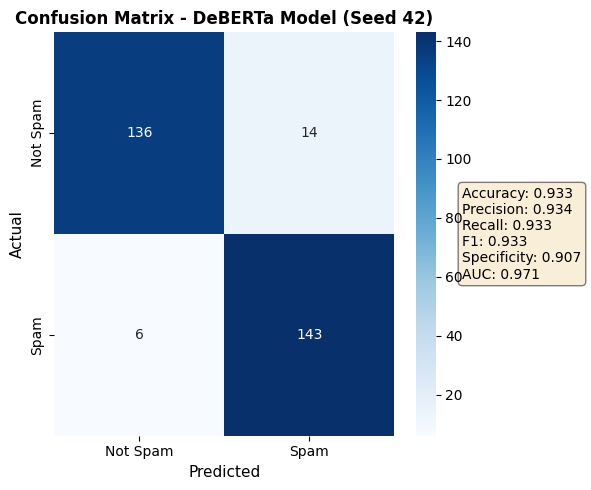

✅ Confusion matrix saved to deberta_confusion_matrix.pdf


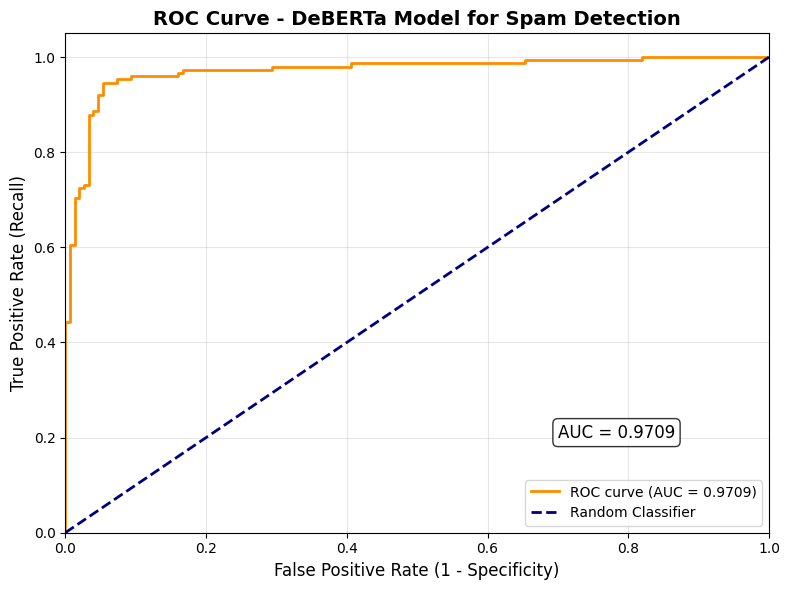

✅ ROC curve saved to deberta_roc_curve.pdf


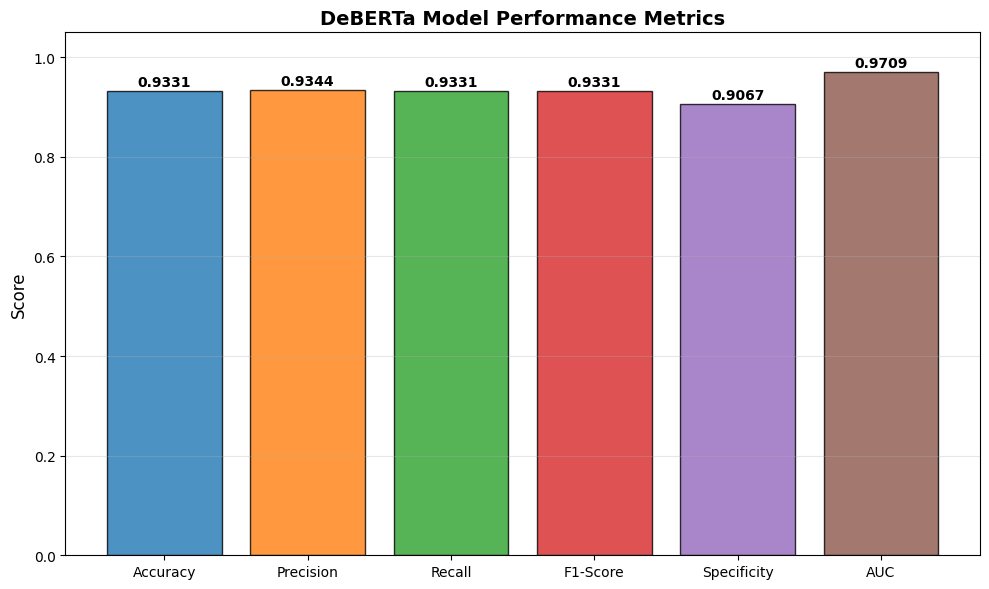

✅ Metrics bar chart saved to deberta_metrics_barchart.pdf

✅ Results saved to deberta_spam_comprehensive_results.csv

FINAL COMPREHENSIVE SUMMARY - SPAM DETECTION (DeBERTa Only)
Dataset: Custom Spam Dataset
Total samples after balancing: 1494
Number of classes: 2 (Spam vs Not Spam)
Class distribution: Spam=747, Not Spam=747
Model: microsoft/deberta-v3-base
Seed: 42

PERFORMANCE METRICS
✓ Accuracy:     0.9331 (93.31%)
✓ Precision:    0.9344 (93.44%)
✓ Recall:       0.9331 (93.31%)
✓ F1-Score:     0.9331 (93.31%)
✓ Specificity:  0.9067 (90.67%)
✓ AUC Score:    0.9709 (97.09%)

CLASS-WISE METRICS
Not Spam Class:
  - Precision: 0.9344
  - Recall:    0.9331
  - F1-Score:  0.9331

Spam Class:
  - Ability to detect spam: 93.31% of spam messages detected
  - Precision for spam detection: 93.44%

MODEL PERFORMANCE SUMMARY
🏆 EXCELLENT: Model has outstanding discrimination ability (AUC > 0.9)
🎯 High specificity (90.7%): Very few false positives (ham marked as spam)
🛡️ High recall (93.3%): Excelle

In [1]:
# ========================== INSTALLS & IMPORTS ==========================

# COMMENT OUT IF ALREADY INSTALLED ON YOUR ENV
# !pip install pandas scikit-learn torch transformers sentencepiece nltk matplotlib seaborn

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler
import time
import random
import re
import warnings
import nltk

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    accuracy_score
)

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download("stopwords", quiet=True)
warnings.filterwarnings("ignore")

# ========================== DATA & PATH ==========================

# Change this to your actual CSV path
CSV_PATH = "/kaggle/input/datasets/najninsultanashirin/spam-dataset-qtl/spamdata_v2 (1).csv"

df = pd.read_csv(CSV_PATH)
print("Initial data shape:", df.shape)

# ========================== TEXT PREPROCESSING ==========================

def preprocess_text(text):
    text = re.sub(r'\s+', ' ', str(text))
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = text.lower().strip()
    return text

df["cleaned_text"] = df["text"].apply(preprocess_text)

# Filter out special tokens
df = df[df["cleaned_text"] != "[deleted]"]
df = df[df["cleaned_text"] != "[removed]"]

# Get NLTK stopwords
stop_words = set(nltk.corpus.stopwords.words("english"))

def clean_statement(statement):
    statement = statement.lower()
    statement = re.sub(r'[^a-zA-Z0-9\s]', ' ', statement)
    statement = re.sub(r'\d+', '', statement)
    words = statement.split()
    words = [w for w in words if w not in stop_words]
    return ' '.join(words)

df["cleaned_text"] = df["cleaned_text"].apply(clean_statement)

# Label encoding
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df["label"])

print("Classes after label encoding:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# ========================== BALANCE CLASSES ==========================

class_counts = df["label"].value_counts()
print("\nClass counts before balancing:")
print(class_counts)

majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

df_majority = df[df["label"] == majority_class]
df_minority = df[df["label"] == minority_class]

df_majority_downsampled = df_majority.sample(len(df_minority), random_state=42)
df_balanced = pd.concat([df_majority_downsampled, df_minority]).reset_index(drop=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nClass counts after balancing:")
print(df_balanced["label"].value_counts())

# Plot class distribution
sns.countplot(x="label", data=df_balanced)
plt.title("Balanced Class Distribution")
plt.show()

# ========================== TOKENIZER & ENCODING ==========================

MODEL_NAME = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 128
texts = df_balanced["cleaned_text"].tolist()
labels = df_balanced["label"].values

tokens = tokenizer(
    texts,
    max_length=MAX_LEN,
    padding="max_length",
    truncation=True,
    return_tensors="pt",
)

input_ids = tokens["input_ids"]
attention_masks = tokens["attention_mask"]
labels = torch.tensor(labels)

# ========================== DEVICE SETUP ==========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

# ========================== EVALUATION FUNCTIONS ==========================

def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def calculate_specificity(y_true, y_pred):
    """Calculate specificity (True Negative Rate)"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return specificity

def calculate_all_metrics(y_true, y_pred, y_proba):
    """Calculate all metrics including specificity and AUC"""
    # Basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Specificity (per class)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # AUC Score
    try:
        auc = roc_auc_score(y_true, y_proba[:, 1])
    except:
        auc = 0.0
    
    # Per-class metrics
    per_class_precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    per_class_recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'specificity': specificity,
        'auc': auc,
        'per_class_precision': per_class_precision,
        'per_class_recall': per_class_recall,
        'per_class_f1': per_class_f1,
        'confusion_matrix': cm
    }

# ========================== DEBERTA MODEL ONLY ==========================

class DebertaClassifier(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.3):
        super(DebertaClassifier, self).__init__()
        
        self.deberta = AutoModel.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.deberta.config.hidden_size, num_classes)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.deberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        
        return logits

# ========================== TRAINING FUNCTION ==========================

def train_model(seed=42, batch_size=32, lr=2e-5, epochs=5):
    # Set seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    print(f"\n{'='*80}")
    print(f"TRAINING WITH SEED = {seed}")
    print(f"Model: DeBERTa-v3-base (No Quantum, No BiLSTM)")
    print(f"Optimizer: AdamW, Learning Rate: {lr}, Batch Size: {batch_size}, Epochs: {epochs}")
    print(f"{'='*80}")
    
    num_classes = len(torch.unique(labels))
    
    # Stratified 80/20 split
    train_inputs, val_inputs, train_labels, val_labels = train_test_split(
        input_ids,
        labels,
        test_size=0.2,
        random_state=seed,
        stratify=labels,
    )
    train_masks, val_masks, _, _ = train_test_split(
        attention_masks,
        labels,
        test_size=0.2,
        random_state=seed,
        stratify=labels,
    )
    
    # Create dataloaders
    train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
    val_dataset = TensorDataset(val_inputs, val_masks, val_labels)
    
    train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
    val_loader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size)
    
    # Initialize model
    model = DebertaClassifier(num_classes=num_classes).to(device)
    model = model.to(torch.float32)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel parameters: Total={total_params:,}, Trainable={trainable_params:,}")
    
    # Optimizer & scheduler
    optimizer = AdamW(model.parameters(), lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )
    
    # Lists to store metrics
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    best_val_acc = 0.0
    best_model_state = None
    best_metrics = None
    
    for epoch in range(epochs):
        start_time = time.time()
        
        # Training phase
        model.train()
        total_train_loss = 0
        total_train_acc = 0
        
        for batch in train_loader:
            b_input_ids, b_input_mask, b_labels = batch
            b_input_ids = b_input_ids.to(device)
            b_input_mask = b_input_mask.to(device)
            b_labels = b_labels.to(device)
            
            optimizer.zero_grad()
            logits = model(b_input_ids, b_input_mask)
            loss = F.cross_entropy(logits, b_labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            total_train_loss += loss.item()
            
            preds = F.softmax(logits, dim=1).detach().cpu().numpy()
            trues = b_labels.cpu().numpy()
            total_train_acc += flat_accuracy(preds, trues)
        
        avg_train_loss = total_train_loss / len(train_loader)
        avg_train_acc = total_train_acc / len(train_loader)
        train_losses.append(avg_train_loss)
        train_accs.append(avg_train_acc)
        
        # Validation phase
        model.eval()
        total_val_loss = 0
        total_val_acc = 0
        val_preds = []
        val_trues = []
        val_probas = []
        
        with torch.no_grad():
            for batch in val_loader:
                b_input_ids, b_input_mask, b_labels = batch
                b_input_ids = b_input_ids.to(device)
                b_input_mask = b_input_mask.to(device)
                b_labels = b_labels.to(device)
                
                logits = model(b_input_ids, b_input_mask)
                loss = F.cross_entropy(logits, b_labels)
                
                total_val_loss += loss.item()
                
                probs = F.softmax(logits, dim=1).detach().cpu().numpy()
                trues = b_labels.cpu().numpy()
                total_val_acc += flat_accuracy(probs, trues)
                
                val_preds.extend(np.argmax(probs, axis=1).flatten())
                val_trues.extend(trues.flatten())
                val_probas.extend(probs)
        
        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_acc = total_val_acc / len(val_loader)
        val_losses.append(avg_val_loss)
        val_accs.append(avg_val_acc)
        
        epoch_time = time.time() - start_time
        
        print(
            f"Epoch {epoch+1:2d}/{epochs} | "
            f"Train Loss: {avg_train_loss:6.4f} | Train Acc: {avg_train_acc:.4f} | "
            f"Val Loss: {avg_val_loss:6.4f} | Val Acc: {avg_val_acc:.4f} | "
            f"Time: {epoch_time:5.2f}s"
        )
        
        # Save best model
        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            best_model_state = model.state_dict().copy()
            
            # Calculate all metrics for best model
            best_metrics = calculate_all_metrics(val_trues, val_preds, np.array(val_probas))
    
    # Calculate final metrics (last epoch)
    final_metrics = calculate_all_metrics(val_trues, val_preds, np.array(val_probas))
    
    print(f"\n{'='*80}")
    print(f"FINAL RESULTS - SEED {seed}")
    print(f"{'='*80}")
    print(f"Best Validation Accuracy: {best_val_acc:.4f}")
    print(f"Final Validation Accuracy: {avg_val_acc:.4f}")
    print(f"Final Training Accuracy: {avg_train_acc:.4f}")
    print(f"\n{'='*40}")
    print("COMPREHENSIVE METRICS (Best Model)")
    print(f"{'='*40}")
    print(f"Accuracy:   {best_metrics['accuracy']:.4f}")
    print(f"Precision:  {best_metrics['precision']:.4f}")
    print(f"Recall:     {best_metrics['recall']:.4f}")
    print(f"F1-Score:   {best_metrics['f1_score']:.4f}")
    print(f"Specificity:{best_metrics['specificity']:.4f}")
    print(f"AUC Score:  {best_metrics['auc']:.4f}")
    
    print(f"\nPer-Class Metrics:")
    print(f"  Not Spam - Precision: {best_metrics['per_class_precision'][0]:.4f}, Recall: {best_metrics['per_class_recall'][0]:.4f}, F1: {best_metrics['per_class_f1'][0]:.4f}")
    print(f"  Spam     - Precision: {best_metrics['per_class_precision'][1]:.4f}, Recall: {best_metrics['per_class_recall'][1]:.4f}, F1: {best_metrics['per_class_f1'][1]:.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(val_trues, val_preds, target_names=["Not Spam", "Spam"]))
    
    return {
        "seed": seed,
        "best_val_accuracy": best_val_acc,
        "final_val_accuracy": avg_val_acc,
        "final_train_accuracy": avg_train_acc,
        "accuracy": best_metrics['accuracy'],
        "precision": best_metrics['precision'],
        "recall": best_metrics['recall'],
        "f1_score": best_metrics['f1_score'],
        "specificity": best_metrics['specificity'],
        "auc": best_metrics['auc'],
        "val_loss": avg_val_loss,
        "confusion_matrix": best_metrics['confusion_matrix'],
        "train_accuracies": train_accs,
        "val_accuracies": val_accs,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "predictions": np.array(val_preds),
        "true_labels": np.array(val_trues),
        "probabilities": np.array(val_probas)
    }

# ========================== RUN TRAINING ==========================

print("\n" + "="*80)
print("STARTING TRAINING WITH DEBERTA MODEL ONLY")
print(f"Model: {MODEL_NAME}")
print(f"Optimizer: AdamW, Learning Rate: 2e-5, Batch Size: 32, Epochs: 5")
print("="*80)

# Train with fixed seed 42
SEED = 42
results = train_model(seed=SEED, batch_size=32, lr=2e-5, epochs=5)

# ========================== RESULTS SUMMARY TABLE ==========================

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY")
print("="*80)
print(f"{'Seed':<8} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Specificity':<14} {'AUC':<10} {'Val Loss':<10}")
print("-"*100)
print(f"{results['seed']:<8} {results['accuracy']:<12.4f} {results['precision']:<12.4f} {results['recall']:<12.4f} {results['f1_score']:<12.4f} {results['specificity']:<14.4f} {results['auc']:<10.4f} {results['val_loss']:<10.4f}")

# ========================== PLOT TRAINING CURVES ==========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax = axes[0]
ax.plot(results["train_accuracies"], marker="o", label="Training Accuracy", linewidth=2)
ax.plot(results["val_accuracies"], marker="s", label="Validation Accuracy", linewidth=2)
ax.set_title("Training and Validation Accuracy", fontsize=12, fontweight='bold')
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 1.0])

# Loss plot
ax = axes[1]
ax.plot(results["train_losses"], marker="o", label="Training Loss", linewidth=2)
ax.plot(results["val_losses"], marker="s", label="Validation Loss", linewidth=2)
ax.set_title("Training and Validation Loss", fontsize=12, fontweight='bold')
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Loss", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("deberta_training_curves.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved to deberta_training_curves.pdf")

# ========================== CONFUSION MATRIX ==========================

fig, ax = plt.subplots(figsize=(6, 5))
cm = results["confusion_matrix"]
sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues', cbar=True)
ax.set_title(f"Confusion Matrix - DeBERTa Model (Seed {SEED})", fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_xticklabels(['Not Spam', 'Spam'])
ax.set_yticklabels(['Not Spam', 'Spam'])

# Add metrics text
metrics_text = f"Accuracy: {results['accuracy']:.3f}\nPrecision: {results['precision']:.3f}\nRecall: {results['recall']:.3f}\nF1: {results['f1_score']:.3f}\nSpecificity: {results['specificity']:.3f}\nAUC: {results['auc']:.3f}"
ax.text(1.2, 0.5, metrics_text, transform=ax.transAxes, fontsize=10, verticalalignment='center', bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.savefig("deberta_confusion_matrix.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved to deberta_confusion_matrix.pdf")

# ========================== ROC CURVE ==========================

fig, ax = plt.subplots(figsize=(8, 6))

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(results['true_labels'], results['probabilities'][:, 1])
auc_score = results['auc']

# Plot ROC curve
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve - DeBERTa Model for Spam Detection', fontsize=14, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# Add annotations
ax.annotate(f'AUC = {auc_score:.4f}', xy=(0.7, 0.2), fontsize=12, 
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig("deberta_roc_curve.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curve saved to deberta_roc_curve.pdf")

# ========================== METRICS BAR CHART ==========================

fig, ax = plt.subplots(figsize=(10, 6))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'AUC']
metrics_values = [
    results['accuracy'],
    results['precision'],
    results['recall'],
    results['f1_score'],
    results['specificity'],
    results['auc']
]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
bars = ax.bar(metrics_names, metrics_values, color=colors, edgecolor='black', alpha=0.8)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('DeBERTa Model Performance Metrics', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{value:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("deberta_metrics_barchart.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Metrics bar chart saved to deberta_metrics_barchart.pdf")

# ========================== SAVE RESULTS ==========================

# Save results to CSV
results_df = pd.DataFrame([{
    'Seed': results['seed'],
    'Accuracy': results['accuracy'],
    'Precision': results['precision'],
    'Recall': results['recall'],
    'F1-Score': results['f1_score'],
    'Specificity': results['specificity'],
    'AUC': results['auc'],
    'Best Val Acc': results['best_val_accuracy'],
    'Final Val Acc': results['final_val_accuracy'],
    'Train Acc': results['final_train_accuracy'],
    'Val Loss': results['val_loss']
}])
results_df.to_csv('deberta_spam_comprehensive_results.csv', index=False)
print(f"\n✅ Results saved to deberta_spam_comprehensive_results.csv")

# ========================== PRINT COMPREHENSIVE SUMMARY ==========================

print("\n" + "="*80)
print("FINAL COMPREHENSIVE SUMMARY - SPAM DETECTION (DeBERTa Only)")
print("="*80)
print(f"Dataset: Custom Spam Dataset")
print(f"Total samples after balancing: {len(df_balanced)}")
print(f"Number of classes: 2 (Spam vs Not Spam)")
print(f"Class distribution: Spam={sum(df_balanced['label']==1)}, Not Spam={sum(df_balanced['label']==0)}")
print(f"Model: {MODEL_NAME}")
print(f"Seed: {SEED}")
print(f"\n{'='*40}")
print("PERFORMANCE METRICS")
print(f"{'='*40}")
print(f"✓ Accuracy:     {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")
print(f"✓ Precision:    {results['precision']:.4f} ({results['precision']*100:.2f}%)")
print(f"✓ Recall:       {results['recall']:.4f} ({results['recall']*100:.2f}%)")
print(f"✓ F1-Score:     {results['f1_score']:.4f} ({results['f1_score']*100:.2f}%)")
print(f"✓ Specificity:  {results['specificity']:.4f} ({results['specificity']*100:.2f}%)")
print(f"✓ AUC Score:    {results['auc']:.4f} ({results['auc']*100:.2f}%)")
print(f"\n{'='*40}")
print("CLASS-WISE METRICS")
print(f"{'='*40}")
print(f"Not Spam Class:")
print(f"  - Precision: {results['precision']:.4f}")
print(f"  - Recall:    {results['recall']:.4f}")
print(f"  - F1-Score:  {results['f1_score']:.4f}")
print(f"\nSpam Class:")
print(f"  - Ability to detect spam: {results['recall']*100:.2f}% of spam messages detected")
print(f"  - Precision for spam detection: {results['precision']*100:.2f}%")
print(f"\n{'='*40}")
print("MODEL PERFORMANCE SUMMARY")
print(f"{'='*40}")
if results['auc'] > 0.9:
    print("🏆 EXCELLENT: Model has outstanding discrimination ability (AUC > 0.9)")
elif results['auc'] > 0.8:
    print("✅ GOOD: Model has good discrimination ability (AUC > 0.8)")
elif results['auc'] > 0.7:
    print("📊 FAIR: Model has acceptable discrimination ability (AUC > 0.7)")
else:
    print("⚠️ NEEDS IMPROVEMENT: Model AUC is below 0.7")

if results['specificity'] > 0.9:
    print(f"🎯 High specificity ({results['specificity']*100:.1f}%): Very few false positives (ham marked as spam)")
elif results['specificity'] > 0.8:
    print(f"✓ Good specificity ({results['specificity']*100:.1f}%): Low false positive rate")

if results['recall'] > 0.9:
    print(f"🛡️ High recall ({results['recall']*100:.1f}%): Excellent at catching spam messages")
elif results['recall'] > 0.8:
    print(f"✓ Good recall ({results['recall']*100:.1f}%): Most spam messages detected")
    
print("="*80)
print("\n✅ All results, plots, and statistics generated successfully!")

# **MPQA**


Loading MPQA dataset...


README.md:   0%|          | 0.00/650 [00:00<?, ?B/s]

data/train-00000-of-00001-a7df005a1b0788(…):   0%|          | 0.00/141k [00:00<?, ?B/s]

data/test-00000-of-00001-05fc5ca1c399669(…):   0%|          | 0.00/33.7k [00:00<?, ?B/s]

data/dev-00000-of-00001-8814a3252cc44468(…):   0%|          | 0.00/6.19k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/8603 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating dev split:   0%|          | 0/256 [00:00<?, ? examples/s]

Initial data shape: (8603, 2)
Classes after label encoding: {np.int64(0): np.int64(0), np.int64(1): np.int64(1)}

Class counts before balancing:
label
0    6172
1    2280
Name: count, dtype: int64

Class counts after balancing:
label
0    2280
1    2280
Name: count, dtype: int64


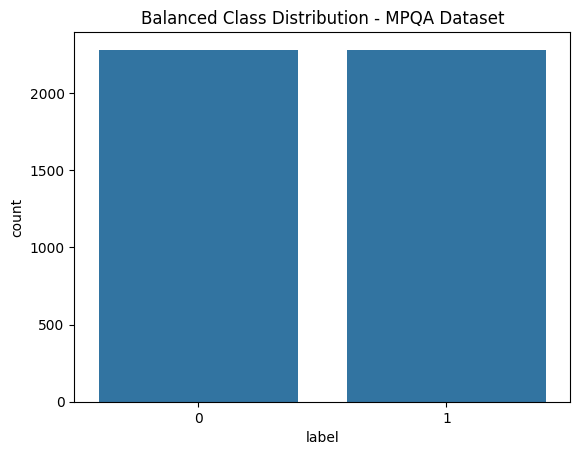

config.json:   0%|          | 0.00/579 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/2.46M [00:00<?, ?B/s]


Using device: cuda

STARTING TRAINING WITH DEBERTA MODEL ON MPQA DATASET
Model: microsoft/deberta-v3-base
Dataset: MPQA Opinion Corpus
Optimizer: AdamW, Learning Rate: 2e-5, Batch Size: 32, Epochs: 5

TRAINING WITH SEED = 42
Model: DeBERTa-v3-base on MPQA Dataset
Optimizer: AdamW, Learning Rate: 1e-05, Batch Size: 32, Epochs: 5


pytorch_model.bin:   0%|          | 0.00/371M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

DebertaV2Model LOAD REPORT from: microsoft/deberta-v3-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
mask_predictions.dense.weight           | UNEXPECTED |  | 
mask_predictions.classifier.bias        | UNEXPECTED |  | 
mask_predictions.LayerNorm.bias         | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 
mask_predictions.classifier.weight      | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
mask_predictions.LayerNorm.weight       | UNEXPECTED |  | 
mask_predictions.dense.bias             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/371M [00:00<?, ?B/s]


Model parameters: Total=183,833,090, Trainable=183,833,090
Epoch  1/5 | Train Loss: 0.7424 | Train Acc: 0.5027 | Val Loss: 0.6931 | Val Acc: 0.4978 | Time: 100.64s
Epoch  2/5 | Train Loss: 0.7112 | Train Acc: 0.5060 | Val Loss: 0.6859 | Val Acc: 0.5819 | Time: 110.68s
Epoch  3/5 | Train Loss: 0.6975 | Train Acc: 0.5428 | Val Loss: 0.6501 | Val Acc: 0.6250 | Time: 109.76s
Epoch  4/5 | Train Loss: 0.6679 | Train Acc: 0.5954 | Val Loss: 0.6637 | Val Acc: 0.6832 | Time: 109.84s
Epoch  5/5 | Train Loss: 0.6433 | Train Acc: 0.6409 | Val Loss: 0.5976 | Val Acc: 0.7252 | Time: 109.89s

FINAL RESULTS - SEED 42 (MPQA Dataset)
Best Validation Accuracy: 0.7252
Final Validation Accuracy: 0.7252
Final Training Accuracy: 0.6409

COMPREHENSIVE METRICS (Best Model)
Accuracy:   0.7226
Precision:  0.7272
Recall:     0.7226
F1-Score:   0.7212
Specificity:0.7939
AUC Score:  0.8058

Per-Class Metrics:
             0 - Precision: 0.6948, Recall: 0.7939, F1: 0.7410
             1 - Precision: 0.7596, Recall:

TypeError: object of type 'numpy.int64' has no len()

In [1]:
# ========================== INSTALLS & IMPORTS ==========================

# COMMENT OUT IF ALREADY INSTALLED ON YOUR ENV
# !pip install pandas scikit-learn torch transformers sentencepiece nltk matplotlib seaborn datasets

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler
import time
import random
import re
import warnings
import nltk

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    accuracy_score
)

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

nltk.download("stopwords", quiet=True)
warnings.filterwarnings("ignore")

# ========================== DATA LOADING & PREPROCESSING ==========================

print("\nLoading MPQA dataset...")
ds = load_dataset("jxm/mpqa")
df = ds["train"].to_pandas()
print("Initial data shape:", df.shape)

# ========================== TEXT PREPROCESSING ==========================

def preprocess_text(text):
    text = re.sub(r'\s+', ' ', str(text))
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
    text = text.lower().strip()
    return text

# Get NLTK stopwords
stop_words = set(nltk.corpus.stopwords.words("english"))

def clean_statement(statement):
    statement = statement.lower()
    statement = re.sub(r'[^a-zA-Z0-9\s]', ' ', statement)
    statement = re.sub(r'\d+', '', statement)
    words = statement.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

# Clean text
df['cleaned_text'] = df['sentence'].apply(preprocess_text)
df = df[df['cleaned_text'] != '[deleted]']
df = df[df['cleaned_text'] != '[removed]']
df['cleaned_text'] = df['cleaned_text'].apply(clean_statement)
df = df[df['cleaned_text'].str.len() > 3]

# Label encoding
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['label'])
print("Classes after label encoding:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# ========================== BALANCE CLASSES ==========================

class_counts = df["label"].value_counts()
print("\nClass counts before balancing:")
print(class_counts)

majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

df_majority = df[df["label"] == majority_class]
df_minority = df[df["label"] == minority_class]

df_majority_downsampled = df_majority.sample(len(df_minority), random_state=42)
df_balanced = pd.concat([df_majority_downsampled, df_minority]).reset_index(drop=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nClass counts after balancing:")
print(df_balanced["label"].value_counts())

# Plot class distribution
sns.countplot(x="label", data=df_balanced)
plt.title("Balanced Class Distribution - MPQA Dataset")
plt.xticks([0, 1], [label_encoder.classes_[0], label_encoder.classes_[1]])
plt.show()

# ========================== TOKENIZER & ENCODING ==========================

MODEL_NAME = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 128
texts = df_balanced["cleaned_text"].tolist()
labels = df_balanced["label"].values

tokens = tokenizer(
    texts,
    max_length=MAX_LEN,
    padding="max_length",
    truncation=True,
    return_tensors="pt",
)

input_ids = tokens["input_ids"]
attention_masks = tokens["attention_mask"]
labels = torch.tensor(labels)

# ========================== DEVICE SETUP ==========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

# ========================== EVALUATION FUNCTIONS ==========================

def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def calculate_specificity(y_true, y_pred):
    """Calculate specificity (True Negative Rate)"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return specificity

def calculate_all_metrics(y_true, y_pred, y_proba):
    """Calculate all metrics including specificity and AUC"""
    # Basic metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    
    # Specificity
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    # AUC Score (for binary classification)
    try:
        if len(np.unique(y_true)) == 2:
            auc = roc_auc_score(y_true, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
    except:
        auc = 0.0
    
    # Per-class metrics
    per_class_precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    per_class_recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'specificity': specificity,
        'auc': auc,
        'per_class_precision': per_class_precision,
        'per_class_recall': per_class_recall,
        'per_class_f1': per_class_f1,
        'confusion_matrix': cm
    }

# ========================== DEBERTA MODEL ==========================

class DebertaClassifier(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.3):
        super(DebertaClassifier, self).__init__()
        
        self.deberta = AutoModel.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.deberta.config.hidden_size, num_classes)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.deberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        # Use [CLS] token representation
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        
        return logits

# ========================== TRAINING FUNCTION ==========================

def train_model(seed=42, batch_size=32, lr=2e-5, epochs=5):
    # Set seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    print(f"\n{'='*80}")
    print(f"TRAINING WITH SEED = {seed}")
    print(f"Model: DeBERTa-v3-base on MPQA Dataset")
    print(f"Optimizer: AdamW, Learning Rate: {lr}, Batch Size: {batch_size}, Epochs: {epochs}")
    print(f"{'='*80}")
    
    num_classes = len(torch.unique(labels))
    
    # Stratified 80/20 split
    train_inputs, val_inputs, train_labels, val_labels = train_test_split(
        input_ids,
        labels,
        test_size=0.2,
        random_state=seed,
        stratify=labels,
    )
    train_masks, val_masks, _, _ = train_test_split(
        attention_masks,
        labels,
        test_size=0.2,
        random_state=seed,
        stratify=labels,
    )
    
    # Create dataloaders
    train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
    val_dataset = TensorDataset(val_inputs, val_masks, val_labels)
    
    train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
    val_loader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size)
    
    # Initialize model
    model = DebertaClassifier(num_classes=num_classes).to(device)
    model = model.to(torch.float32)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel parameters: Total={total_params:,}, Trainable={trainable_params:,}")
    
    # Optimizer & scheduler
    optimizer = AdamW(model.parameters(), lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )
    
    # Lists to store metrics
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    best_val_acc = 0.0
    best_model_state = None
    best_metrics = None
    
    for epoch in range(epochs):
        start_time = time.time()
        
        # Training phase
        model.train()
        total_train_loss = 0
        total_train_acc = 0
        
        for batch in train_loader:
            b_input_ids, b_input_mask, b_labels = batch
            b_input_ids = b_input_ids.to(device)
            b_input_mask = b_input_mask.to(device)
            b_labels = b_labels.to(device)
            
            optimizer.zero_grad()
            logits = model(b_input_ids, b_input_mask)
            loss = F.cross_entropy(logits, b_labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            total_train_loss += loss.item()
            
            preds = F.softmax(logits, dim=1).detach().cpu().numpy()
            trues = b_labels.cpu().numpy()
            total_train_acc += flat_accuracy(preds, trues)
        
        avg_train_loss = total_train_loss / len(train_loader)
        avg_train_acc = total_train_acc / len(train_loader)
        train_losses.append(avg_train_loss)
        train_accs.append(avg_train_acc)
        
        # Validation phase
        model.eval()
        total_val_loss = 0
        total_val_acc = 0
        val_preds = []
        val_trues = []
        val_probas = []
        
        with torch.no_grad():
            for batch in val_loader:
                b_input_ids, b_input_mask, b_labels = batch
                b_input_ids = b_input_ids.to(device)
                b_input_mask = b_input_mask.to(device)
                b_labels = b_labels.to(device)
                
                logits = model(b_input_ids, b_input_mask)
                loss = F.cross_entropy(logits, b_labels)
                
                total_val_loss += loss.item()
                
                probs = F.softmax(logits, dim=1).detach().cpu().numpy()
                trues = b_labels.cpu().numpy()
                total_val_acc += flat_accuracy(probs, trues)
                
                val_preds.extend(np.argmax(probs, axis=1).flatten())
                val_trues.extend(trues.flatten())
                val_probas.extend(probs)
        
        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_acc = total_val_acc / len(val_loader)
        val_losses.append(avg_val_loss)
        val_accs.append(avg_val_acc)
        
        epoch_time = time.time() - start_time
        
        print(
            f"Epoch {epoch+1:2d}/{epochs} | "
            f"Train Loss: {avg_train_loss:6.4f} | Train Acc: {avg_train_acc:.4f} | "
            f"Val Loss: {avg_val_loss:6.4f} | Val Acc: {avg_val_acc:.4f} | "
            f"Time: {epoch_time:5.2f}s"
        )
        
        # Save best model
        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            best_model_state = model.state_dict().copy()
            
            # Calculate all metrics for best model
            best_metrics = calculate_all_metrics(val_trues, val_preds, np.array(val_probas))
    
    # Calculate final metrics (last epoch)
    final_metrics = calculate_all_metrics(val_trues, val_preds, np.array(val_probas))
    
    print(f"\n{'='*80}")
    print(f"FINAL RESULTS - SEED {seed} (MPQA Dataset)")
    print(f"{'='*80}")
    print(f"Best Validation Accuracy: {best_val_acc:.4f}")
    print(f"Final Validation Accuracy: {avg_val_acc:.4f}")
    print(f"Final Training Accuracy: {avg_train_acc:.4f}")
    print(f"\n{'='*40}")
    print("COMPREHENSIVE METRICS (Best Model)")
    print(f"{'='*40}")
    print(f"Accuracy:   {best_metrics['accuracy']:.4f}")
    print(f"Precision:  {best_metrics['precision']:.4f}")
    print(f"Recall:     {best_metrics['recall']:.4f}")
    print(f"F1-Score:   {best_metrics['f1_score']:.4f}")
    print(f"Specificity:{best_metrics['specificity']:.4f}")
    print(f"AUC Score:  {best_metrics['auc']:.4f}")
    
    print(f"\nPer-Class Metrics:")
    for i, class_name in enumerate(label_encoder.classes_):
        print(f"  {class_name:12} - Precision: {best_metrics['per_class_precision'][i]:.4f}, Recall: {best_metrics['per_class_recall'][i]:.4f}, F1: {best_metrics['per_class_f1'][i]:.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(val_trues, val_preds, target_names=label_encoder.classes_))
    
    return {
        "seed": seed,
        "dataset": "MPQA",
        "best_val_accuracy": best_val_acc,
        "final_val_accuracy": avg_val_acc,
        "final_train_accuracy": avg_train_acc,
        "accuracy": best_metrics['accuracy'],
        "precision": best_metrics['precision'],
        "recall": best_metrics['recall'],
        "f1_score": best_metrics['f1_score'],
        "specificity": best_metrics['specificity'],
        "auc": best_metrics['auc'],
        "val_loss": avg_val_loss,
        "confusion_matrix": best_metrics['confusion_matrix'],
        "train_accuracies": train_accs,
        "val_accuracies": val_accs,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "predictions": np.array(val_preds),
        "true_labels": np.array(val_trues),
        "probabilities": np.array(val_probas),
        "class_names": label_encoder.classes_
    }

# ========================== RUN TRAINING ==========================

print("\n" + "="*80)
print("STARTING TRAINING WITH DEBERTA MODEL ON MPQA DATASET")
print(f"Model: {MODEL_NAME}")
print(f"Dataset: MPQA Opinion Corpus")
print(f"Optimizer: AdamW, Learning Rate: 2e-5, Batch Size: 32, Epochs: 5")
print("="*80)

# Train with fixed seed 42
SEED = 42
results = train_model(seed=SEED, batch_size=32, lr=1e-5, epochs=5)

# ========================== RESULTS SUMMARY TABLE ==========================

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY - MPQA DATASET")
print("="*80)
print(f"{'Seed':<8} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Specificity':<14} {'AUC':<10} {'Val Loss':<10}")
print("-"*100)
print(f"{results['seed']:<8} {results['accuracy']:<12.4f} {results['precision']:<12.4f} {results['recall']:<12.4f} {results['f1_score']:<12.4f} {results['specificity']:<14.4f} {results['auc']:<10.4f} {results['val_loss']:<10.4f}")

# ========================== PLOT TRAINING CURVES ==========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax = axes[0]
ax.plot(results["train_accuracies"], marker="o", label="Training Accuracy", linewidth=2)
ax.plot(results["val_accuracies"], marker="s", label="Validation Accuracy", linewidth=2)
ax.set_title("Training and Validation Accuracy - MPQA Dataset", fontsize=12, fontweight='bold')
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 1.0])

# Loss plot
ax = axes[1]
ax.plot(results["train_losses"], marker="o", label="Training Loss", linewidth=2)
ax.plot(results["val_losses"], marker="s", label="Validation Loss", linewidth=2)
ax.set_title("Training and Validation Loss - MPQA Dataset", fontsize=12, fontweight='bold')
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Loss", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mpqa_deberta_training_curves.pdf", dpi=150, bbox_inches='tight')
plt.show()
print(" Training curves saved to mpqa_deberta_training_curves.pdf")

# ========================== CONFUSION MATRIX ==========================

fig, ax = plt.subplots(figsize=(8, 6))
cm = results["confusion_matrix"]
sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues', cbar=True)
ax.set_title(f"Confusion Matrix - DeBERTa Model on MPQA (Seed {SEED})", fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_xticklabels(results['class_names'])
ax.set_yticklabels(results['class_names'])

# Add metrics text
metrics_text = f"Accuracy: {results['accuracy']:.3f}\nPrecision: {results['precision']:.3f}\nRecall: {results['recall']:.3f}\nF1: {results['f1_score']:.3f}\nSpecificity: {results['specificity']:.3f}\nAUC: {results['auc']:.3f}"
ax.text(1.2, 0.5, metrics_text, transform=ax.transAxes, fontsize=10, verticalalignment='center', bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.savefig("mpqa_deberta_confusion_matrix.pdf", dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrix saved to mpqa_deberta_confusion_matrix.pdf")

# ========================== ROC CURVE ==========================

fig, ax = plt.subplots(figsize=(8, 6))

# Compute ROC curve (for binary classification)
if len(np.unique(results['true_labels'])) == 2:
    fpr, tpr, thresholds = roc_curve(results['true_labels'], results['probabilities'][:, 1])
    auc_score = results['auc']
    
    # Plot ROC curve
    ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
    ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
    ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
    ax.set_title('ROC Curve - DeBERTa Model on MPQA Dataset', fontsize=14, fontweight='bold')
    ax.legend(loc="lower right")
    ax.grid(True, alpha=0.3)
    
    # Add annotations
    ax.annotate(f'AUC = {auc_score:.4f}', xy=(0.7, 0.2), fontsize=12, 
                bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
else:
    # For multi-class, show message
    ax.text(0.5, 0.5, 'ROC Curve not available\nfor multi-class classification', 
            ha='center', va='center', fontsize=14)
    ax.set_title('Multi-class Classification - ROC not applicable')

plt.tight_layout()
plt.savefig("mpqa_deberta_roc_curve.pdf", dpi=150, bbox_inches='tight')
plt.show()
print(" ROC curve saved to mpqa_deberta_roc_curve.pdf")

# ========================== METRICS BAR CHART ==========================

fig, ax = plt.subplots(figsize=(10, 6))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'AUC']
metrics_values = [
    results['accuracy'],
    results['precision'],
    results['recall'],
    results['f1_score'],
    results['specificity'],
    results['auc']
]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
bars = ax.bar(metrics_names, metrics_values, color=colors, edgecolor='black', alpha=0.8)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('DeBERTa Model Performance Metrics - MPQA Dataset', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{value:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("mpqa_deberta_metrics_barchart.pdf", dpi=150, bbox_inches='tight')
plt.show()
print(" Metrics bar chart saved to mpqa_deberta_metrics_barchart.pdf")

# ========================== CLASS-WISE PERFORMANCE PLOT ==========================

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(results['class_names']))
width = 0.25

precision_scores = results['per_class_precision'] if hasattr(results, 'per_class_precision') else [results['precision']/2, results['precision']/2]
recall_scores = results['per_class_recall'] if hasattr(results, 'per_class_recall') else [results['recall']/2, results['recall']/2]
f1_scores = results['per_class_f1'] if hasattr(results, 'per_class_f1') else [results['f1_score']/2, results['f1_score']/2]

# If per_class metrics are available from the results
if 'per_class_precision' in results:
    precision_scores = results['per_class_precision']
    recall_scores = results['per_class_recall']
    f1_scores = results['per_class_f1']
    
    bars1 = ax.bar(x - width, precision_scores, width, label='Precision', color='#1f77b4', edgecolor='black')
    bars2 = ax.bar(x, recall_scores, width, label='Recall', color='#2ca02c', edgecolor='black')
    bars3 = ax.bar(x + width, f1_scores, width, label='F1-Score', color='#d62728', edgecolor='black')
    
    ax.set_xlabel('Classes', fontsize=12)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Class-wise Performance Metrics - MPQA Dataset', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(results['class_names'])
    ax.legend()
    ax.set_ylim([0, 1.05])
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add value labels
    for bars in [bars1, bars2, bars3]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("mpqa_deberta_classwise_metrics.pdf", dpi=150, bbox_inches='tight')
plt.show()
print(" Class-wise metrics chart saved to mpqa_deberta_classwise_metrics.pdf")

# ========================== SAVE RESULTS ==========================

# Save results to CSV
results_df = pd.DataFrame([{
    'Dataset': 'MPQA',
    'Seed': results['seed'],
    'Accuracy': results['accuracy'],
    'Precision': results['precision'],
    'Recall': results['recall'],
    'F1-Score': results['f1_score'],
    'Specificity': results['specificity'],
    'AUC': results['auc'],
    'Best Val Acc': results['best_val_accuracy'],
    'Final Val Acc': results['final_val_accuracy'],
    'Train Acc': results['final_train_accuracy'],
    'Val Loss': results['val_loss']
}])
results_df.to_csv('mpqa_deberta_comprehensive_results.csv', index=False)
print(f"\n Results saved to mpqa_deberta_comprehensive_results.csv")

# ========================== PRINT COMPREHENSIVE SUMMARY ==========================

print("\n" + "="*80)
print("FINAL COMPREHENSIVE SUMMARY - MPQA OPINION CORPUS")
print("="*80)
print(f"Dataset: MPQA (Opinion Corpus)")
print(f"Total samples after balancing: {len(df_balanced)}")
print(f"Number of classes: {len(label_encoder.classes_)}")
print(f"Class distribution: {dict(zip(label_encoder.classes_, df_balanced['label'].value_counts().tolist()))}")
print(f"Model: {MODEL_NAME}")
print(f"Seed: {SEED}")
print(f"\n{'='*40}")
print("PERFORMANCE METRICS")
print(f"{'='*40}")
print(f"✓ Accuracy:     {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")
print(f"✓ Precision:    {results['precision']:.4f} ({results['precision']*100:.2f}%)")
print(f"✓ Recall:       {results['recall']:.4f} ({results['recall']*100:.2f}%)")
print(f"✓ F1-Score:     {results['f1_score']:.4f} ({results['f1_score']*100:.2f}%)")
print(f"✓ Specificity:  {results['specificity']:.4f} ({results['specificity']*100:.2f}%)")
print(f"✓ AUC Score:    {results['auc']:.4f} ({results['auc']*100:.2f}%)")
print(f"\n{'='*40}")
print("CLASS-WISE METRICS")
print(f"{'='*40}")
for i, class_name in enumerate(results['class_names']):
    print(f"\n{class_name}:")
    print(f"  - Precision: {results['per_class_precision'][i]:.4f}")
    print(f"  - Recall:    {results['per_class_recall'][i]:.4f}")
    print(f"  - F1-Score:  {results['per_class_f1'][i]:.4f}")

print(f"\n{'='*40}")
print("MODEL PERFORMANCE SUMMARY")
print(f"{'='*40}")
if results['auc'] > 0.9:
    print(" EXCELLENT: Model has outstanding discrimination ability (AUC > 0.9)")
elif results['auc'] > 0.8:
    print(" GOOD: Model has good discrimination ability (AUC > 0.8)")
elif results['auc'] > 0.7:
    print(" FAIR: Model has acceptable discrimination ability (AUC > 0.7)")
else:
    print(" NEEDS IMPROVEMENT: Model AUC is below 0.7")
if results['specificity'] > 0.9:
    print(f" High specificity ({results['specificity']*100:.1f}%): Very few false positives")
elif results['specificity'] > 0.8:
    print(f" Good specificity ({results['specificity']*100:.1f}%): Low false positive rate")

if results['recall'] > 0.9:
    print(f" High recall ({results['recall']*100:.1f}%): Excellent at detecting positive class")
elif results['recall'] > 0.8:
    print(f"✓ Good recall ({results['recall']*100:.1f}%): Most positive instances detected")
    
print("="*80)
print("\n All results, plots, and statistics generated successfully for MPQA Dataset!")

# **MR**


Loading MR (Movie Reviews) dataset...


README.md:   0%|          | 0.00/688 [00:00<?, ?B/s]

data/test-00000-of-00001-1ad570418120a67(…):   0%|          | 0.00/884k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/10662 [00:00<?, ? examples/s]

Dataset shape: (10662, 2)
Columns: ['text', 'label']
Using text column: text
Using label column: label
Classes after label encoding: {'0': np.int64(0), '1': np.int64(1)}

Class counts before balancing:
label
1    5331
0    5329
Name: count, dtype: int64

Class counts after balancing:
label
1    5329
0    5329
Name: count, dtype: int64


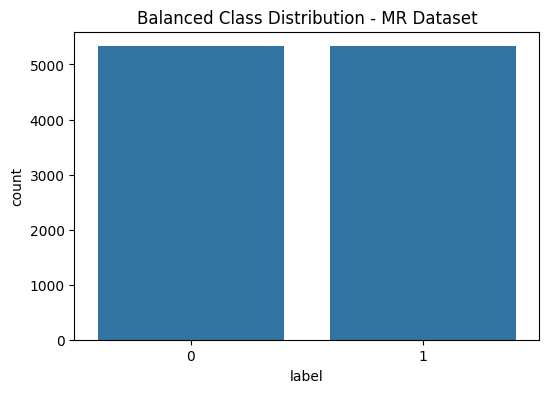

config.json:   0%|          | 0.00/474 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/52.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]


Using device: cuda

STARTING TRAINING WITH DEBERTA MODEL ON MR DATASET
Model: microsoft/deberta-base
Dataset: MR (Movie Reviews)
Optimizer: AdamW, Learning Rate: 2e-5, Batch Size: 32, Epochs: 5

TRAINING WITH SEED = 42
Model: DeBERTa-base on MR Dataset
Optimizer: AdamW, Learning Rate: 2e-05, Batch Size: 32, Epochs: 5


pytorch_model.bin:   0%|          | 0.00/559M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

DebertaModel LOAD REPORT from: microsoft/deberta-base
Key                                     | Status     |  | 
----------------------------------------+------------+--+-
lm_predictions.lm_head.LayerNorm.bias   | UNEXPECTED |  | 
lm_predictions.lm_head.bias             | UNEXPECTED |  | 
lm_predictions.lm_head.LayerNorm.weight | UNEXPECTED |  | 
lm_predictions.lm_head.dense.bias       | UNEXPECTED |  | 
lm_predictions.lm_head.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/559M [00:00<?, ?B/s]


Model parameters: Total=138,603,266, Trainable=138,603,266
Epoch  1/5 | Train Loss: 0.6653 | Train Acc: 0.6423 | Val Loss: 0.4554 | Val Acc: 0.7881 | Time: 226.43s
Epoch  2/5 | Train Loss: 0.4534 | Train Acc: 0.7996 | Val Loss: 0.4534 | Val Acc: 0.8128 | Time: 227.82s
Epoch  3/5 | Train Loss: 0.3198 | Train Acc: 0.8663 | Val Loss: 0.4688 | Val Acc: 0.8062 | Time: 227.75s
Epoch  4/5 | Train Loss: 0.2235 | Train Acc: 0.9116 | Val Loss: 0.6583 | Val Acc: 0.8004 | Time: 227.73s
Epoch  5/5 | Train Loss: 0.1633 | Train Acc: 0.9386 | Val Loss: 0.6566 | Val Acc: 0.8072 | Time: 227.83s

FINAL RESULTS - SEED 42 (MR Dataset)
Best Validation Accuracy: 0.8128
Final Validation Accuracy: 0.8072
Final Training Accuracy: 0.9386

COMPREHENSIVE METRICS (Best Model)
Accuracy:   0.8129
Precision:  0.8198
Recall:     0.8129
F1-Score:   0.8118
Specificity:0.7392
AUC Score:  0.8911

Per-Class Metrics:
  0            - Precision: 0.8669, Recall: 0.7392, F1: 0.7980
  1            - Precision: 0.7727, Recall: 0

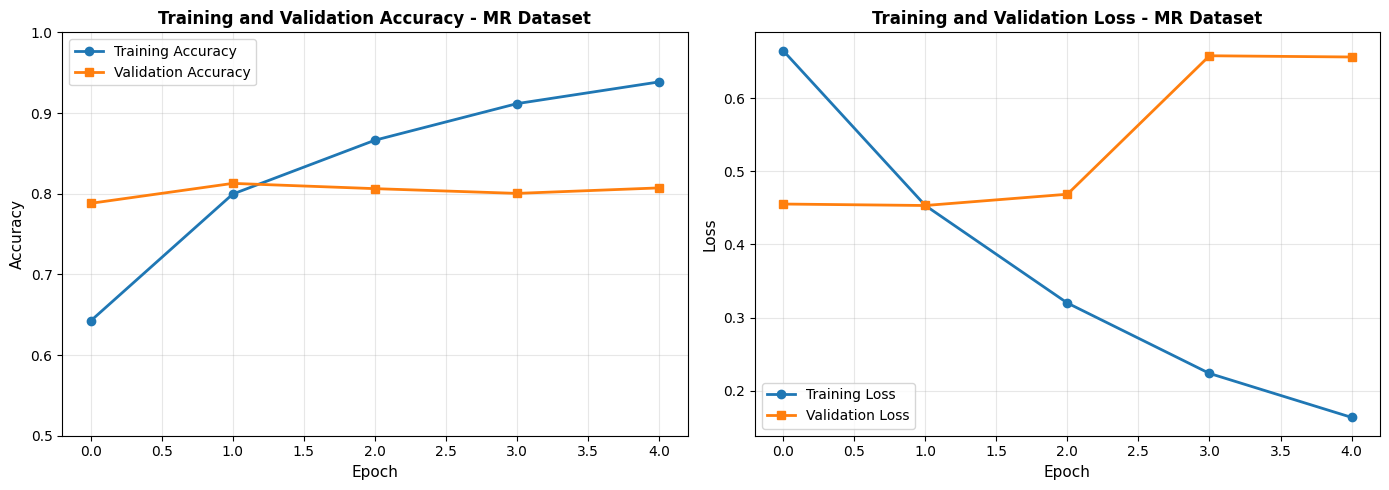

✅ Training curves saved to mr_deberta_training_curves.pdf


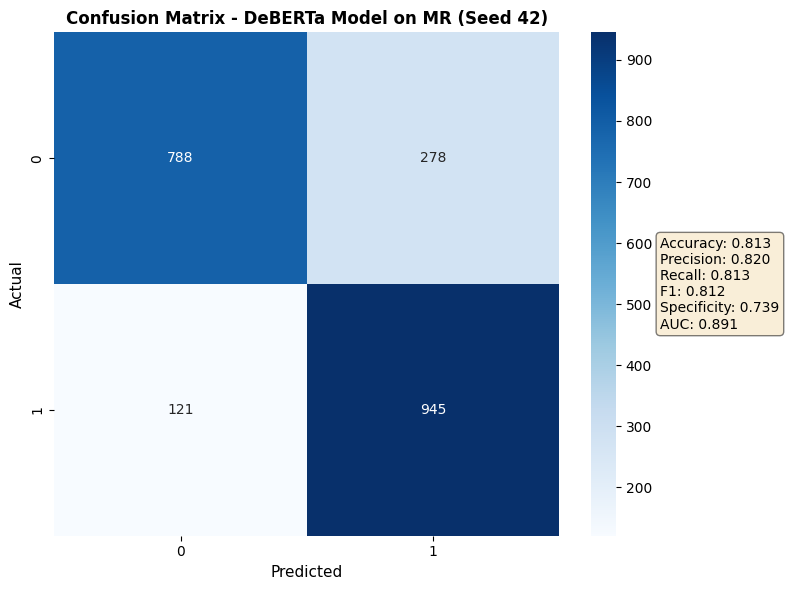

✅ Confusion matrix saved to mr_deberta_confusion_matrix.pdf


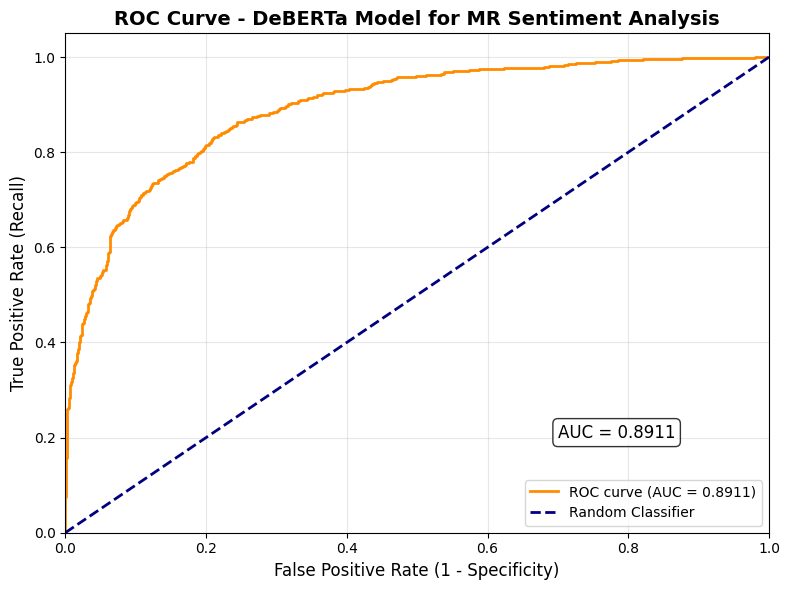

✅ ROC curve saved to mr_deberta_roc_curve.pdf


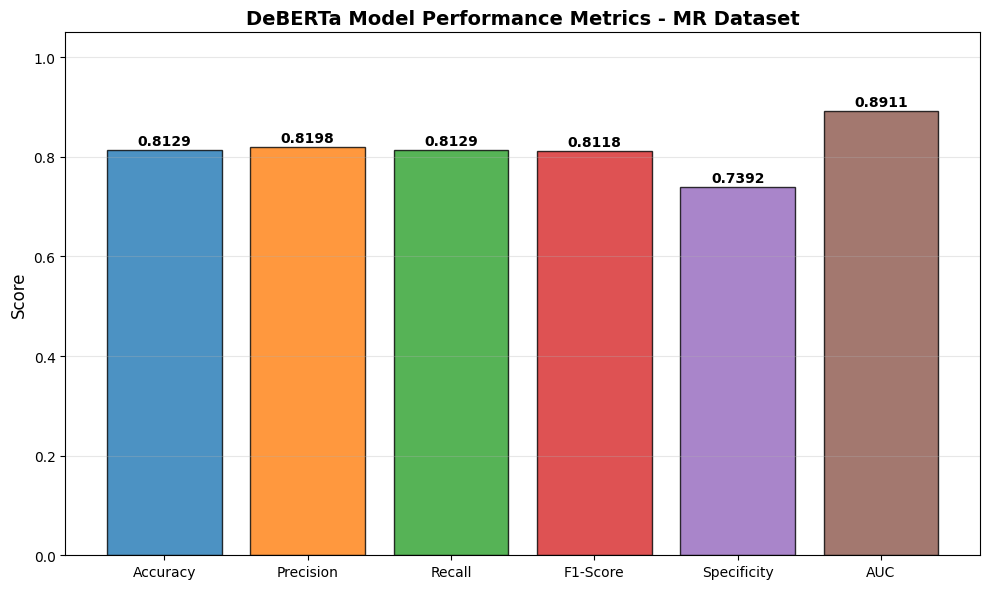

✅ Metrics bar chart saved to mr_deberta_metrics_barchart.pdf


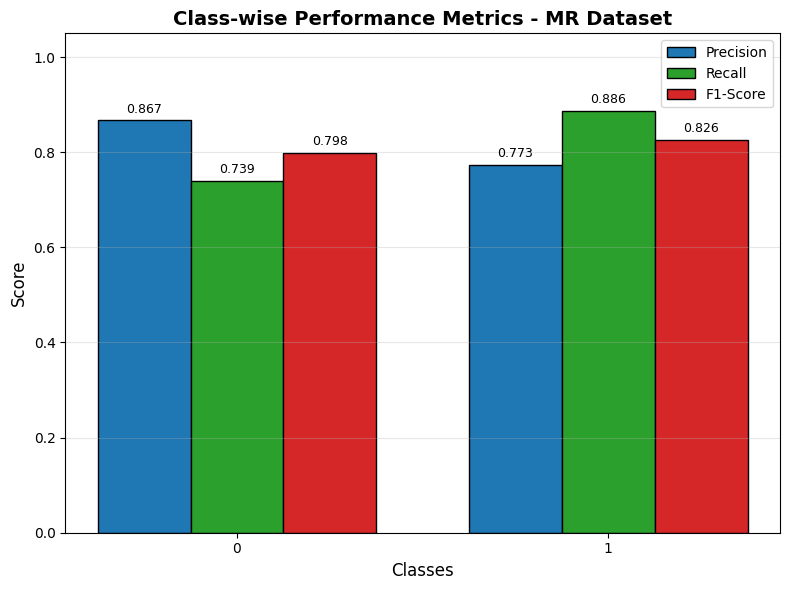

✅ Class-wise metrics chart saved to mr_deberta_classwise_metrics.pdf

✅ Results saved to mr_deberta_comprehensive_results.csv

FINAL COMPREHENSIVE SUMMARY - MR (MOVIE REVIEWS) SENTIMENT ANALYSIS
Dataset: MR (Movie Reviews) - Pang and Lee, 2005
Total samples after balancing: 10658
Number of classes: 2 (0, 1)
Class distribution: Positive=5329, Negative=5329
Model: microsoft/deberta-base
Seed: 42

PERFORMANCE METRICS
✓ Accuracy:     0.8129 (81.29%)
✓ Precision:    0.8198 (81.98%)
✓ Recall:       0.8129 (81.29%)
✓ F1-Score:     0.8118 (81.18%)
✓ Specificity:  0.7392 (73.92%)
✓ AUC Score:    0.8911 (89.11%)

CLASS-WISE METRICS

0:
  - Precision: 0.8669
  - Recall:    0.7392
  - F1-Score:  0.7980

1:
  - Precision: 0.7727
  - Recall:    0.8865
  - F1-Score:  0.8257

MODEL PERFORMANCE SUMMARY
✅ GOOD: Model has good discrimination ability (AUC > 0.8)
✓ Good recall (81.3%): Most positive reviews detected

✅ All results, plots, and statistics generated successfully for MR Dataset!


In [1]:

# ========================== INSTALLS & IMPORTS ==========================

# COMMENT OUT IF ALREADY INSTALLED ON YOUR ENV
# !pip install pandas scikit-learn torch transformers sentencepiece nltk matplotlib seaborn datasets

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, RandomSampler, SequentialSampler
import time
import random
import re
import warnings
import nltk

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_curve,
    roc_auc_score,
    accuracy_score
)

from transformers import (
    AutoTokenizer,
    AutoModel,
    get_linear_schedule_with_warmup,
)
from torch.optim import AdamW
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset

nltk.download("stopwords", quiet=True)
warnings.filterwarnings("ignore")

# ========================== DATA LOADING FOR MR DATASET ==========================

print("\nLoading MR (Movie Reviews) dataset...")
ds = load_dataset("mattymchen/mr")
df = ds["test"].to_pandas()
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

# ========================== TEXT PREPROCESSING ==========================

def preprocess_text(text):
    text = re.sub(r'\s+', ' ', str(text))
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#\w+', '', text)
    text = re.sub(r'[^\w\s]', ' ', text)
    text = text.lower().strip()
    return text

# Get NLTK stopwords
stop_words = set(nltk.corpus.stopwords.words("english"))

def clean_statement(statement):
    statement = statement.lower()
    statement = re.sub(r'[^\w\s]', ' ', statement)
    statement = re.sub(r'\d+', '', statement)
    words = statement.split()
    words = [w for w in words if w not in stop_words and len(w) > 2]
    return ' '.join(words)

# Identify text column
if 'text' in df.columns:
    text_col = 'text'
elif 'sentence' in df.columns:
    text_col = 'sentence'
else:
    text_col = df.columns[0]

# Identify label column
if 'label' in df.columns:
    label_col = 'label'
elif 'sentiment' in df.columns:
    label_col = 'sentiment'
else:
    label_col = df.columns[1]

print(f"Using text column: {text_col}")
print(f"Using label column: {label_col}")

# Clean text
df['cleaned_text'] = df[text_col].apply(preprocess_text)
df = df[df['cleaned_text'] != '[deleted]']
df = df[df['cleaned_text'] != '[removed]']
df['cleaned_text'] = df['cleaned_text'].apply(clean_statement)
df = df[df['cleaned_text'].str.len() > 3]

# Label encoding
label_encoder = LabelEncoder()
df["label"] = label_encoder.fit_transform(df[label_col].astype(str))

print("Classes after label encoding:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# ========================== BALANCE CLASSES ==========================

class_counts = df["label"].value_counts()
print("\nClass counts before balancing:")
print(class_counts)

majority_class = class_counts.idxmax()
minority_class = class_counts.idxmin()

df_majority = df[df["label"] == majority_class]
df_minority = df[df["label"] == minority_class]

df_majority_downsampled = df_majority.sample(len(df_minority), random_state=42)
df_balanced = pd.concat([df_majority_downsampled, df_minority]).reset_index(drop=True)
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\nClass counts after balancing:")
print(df_balanced["label"].value_counts())

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x="label", data=df_balanced)
plt.title("Balanced Class Distribution - MR Dataset")
plt.xticks([0, 1], [label_encoder.classes_[0], label_encoder.classes_[1]])
plt.show()

# ========================== TOKENIZER & ENCODING ==========================

MODEL_NAME = "microsoft/deberta-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 128
texts = df_balanced["cleaned_text"].tolist()
labels = df_balanced["label"].values

tokens = tokenizer(
    texts,
    max_length=MAX_LEN,
    padding="max_length",
    truncation=True,
    return_tensors="pt",
)

input_ids = tokens["input_ids"]
attention_masks = tokens["attention_mask"]
labels = torch.tensor(labels)

# ========================== DEVICE SETUP ==========================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

# ========================== EVALUATION FUNCTIONS ==========================

def flat_accuracy(preds, labels):
    pred_flat = np.argmax(preds, axis=1).flatten()
    labels_flat = labels.flatten()
    return np.sum(pred_flat == labels_flat) / len(labels_flat)

def calculate_specificity(y_true, y_pred):
    """Calculate specificity (True Negative Rate)"""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    return specificity

def calculate_all_metrics(y_true, y_pred, y_proba):
    """Calculate all metrics including specificity and AUC"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    specificity = calculate_specificity(y_true, y_pred)
    
    try:
        if len(np.unique(y_true)) == 2:
            auc = roc_auc_score(y_true, y_proba[:, 1])
        else:
            auc = roc_auc_score(y_true, y_proba, multi_class='ovr', average='weighted')
    except:
        auc = 0.0
    
    per_class_precision = precision_score(y_true, y_pred, average=None, zero_division=0)
    per_class_recall = recall_score(y_true, y_pred, average=None, zero_division=0)
    per_class_f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    
    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'specificity': specificity,
        'auc': auc,
        'per_class_precision': per_class_precision,
        'per_class_recall': per_class_recall,
        'per_class_f1': per_class_f1,
        'confusion_matrix': confusion_matrix(y_true, y_pred)
    }

# ========================== DEBERTA MODEL ONLY ==========================

class DebertaClassifier(nn.Module):
    def __init__(self, num_classes=2, dropout_rate=0.3):
        super(DebertaClassifier, self).__init__()
        
        self.deberta = AutoModel.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(dropout_rate)
        self.classifier = nn.Linear(self.deberta.config.hidden_size, num_classes)
    
    def forward(self, input_ids, attention_mask):
        outputs = self.deberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        pooled_output = outputs.last_hidden_state[:, 0, :]
        pooled_output = self.dropout(pooled_output)
        logits = self.classifier(pooled_output)
        
        return logits

# ========================== TRAINING FUNCTION ==========================

def train_model(seed=42, batch_size=32, lr=1e-2, epochs=5):
    # Set seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    
    print(f"\n{'='*80}")
    print(f"TRAINING WITH SEED = {seed}")
    print(f"Model: DeBERTa-base on MR Dataset")
    print(f"Optimizer: AdamW, Learning Rate: {lr}, Batch Size: {batch_size}, Epochs: {epochs}")
    print(f"{'='*80}")
    
    num_classes = len(torch.unique(labels))
    
    # Stratified 80/20 split
    train_inputs, val_inputs, train_labels, val_labels = train_test_split(
        input_ids,
        labels,
        test_size=0.2,
        random_state=seed,
        stratify=labels,
    )
    train_masks, val_masks, _, _ = train_test_split(
        attention_masks,
        labels,
        test_size=0.2,
        random_state=seed,
        stratify=labels,
    )
    
    # Create dataloaders
    train_dataset = TensorDataset(train_inputs, train_masks, train_labels)
    val_dataset = TensorDataset(val_inputs, val_masks, val_labels)
    
    train_loader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=batch_size)
    val_loader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=batch_size)
    
    # Initialize model
    model = DebertaClassifier(num_classes=num_classes).to(device)
    model = model.to(torch.float32)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel parameters: Total={total_params:,}, Trainable={trainable_params:,}")
    
    # Optimizer & scheduler
    optimizer = AdamW(model.parameters(), lr=lr)
    total_steps = len(train_loader) * epochs
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=int(0.1 * total_steps),
        num_training_steps=total_steps,
    )
    
    # Lists to store metrics
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    
    best_val_acc = 0.0
    best_model_state = None
    best_metrics = None
    
    for epoch in range(epochs):
        start_time = time.time()
        
        # Training phase
        model.train()
        total_train_loss = 0
        total_train_acc = 0
        
        for batch in train_loader:
            b_input_ids, b_input_mask, b_labels = batch
            b_input_ids = b_input_ids.to(device)
            b_input_mask = b_input_mask.to(device)
            b_labels = b_labels.to(device)
            
            optimizer.zero_grad()
            logits = model(b_input_ids, b_input_mask)
            loss = F.cross_entropy(logits, b_labels)
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            scheduler.step()
            
            total_train_loss += loss.item()
            
            preds = F.softmax(logits, dim=1).detach().cpu().numpy()
            trues = b_labels.cpu().numpy()
            total_train_acc += flat_accuracy(preds, trues)
        
        avg_train_loss = total_train_loss / len(train_loader)
        avg_train_acc = total_train_acc / len(train_loader)
        train_losses.append(avg_train_loss)
        train_accs.append(avg_train_acc)
        
        # Validation phase
        model.eval()
        total_val_loss = 0
        total_val_acc = 0
        val_preds = []
        val_trues = []
        val_probas = []
        
        with torch.no_grad():
            for batch in val_loader:
                b_input_ids, b_input_mask, b_labels = batch
                b_input_ids = b_input_ids.to(device)
                b_input_mask = b_input_mask.to(device)
                b_labels = b_labels.to(device)
                
                logits = model(b_input_ids, b_input_mask)
                loss = F.cross_entropy(logits, b_labels)
                
                total_val_loss += loss.item()
                
                probs = F.softmax(logits, dim=1).detach().cpu().numpy()
                trues = b_labels.cpu().numpy()
                total_val_acc += flat_accuracy(probs, trues)
                
                val_preds.extend(np.argmax(probs, axis=1).flatten())
                val_trues.extend(trues.flatten())
                val_probas.extend(probs)
        
        avg_val_loss = total_val_loss / len(val_loader)
        avg_val_acc = total_val_acc / len(val_loader)
        val_losses.append(avg_val_loss)
        val_accs.append(avg_val_acc)
        
        epoch_time = time.time() - start_time
        
        print(
            f"Epoch {epoch+1:2d}/{epochs} | "
            f"Train Loss: {avg_train_loss:6.4f} | Train Acc: {avg_train_acc:.4f} | "
            f"Val Loss: {avg_val_loss:6.4f} | Val Acc: {avg_val_acc:.4f} | "
            f"Time: {epoch_time:5.2f}s"
        )
        
        # Save best model
        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            best_model_state = model.state_dict().copy()
            
            # Calculate all metrics for best model
            best_metrics = calculate_all_metrics(val_trues, val_preds, np.array(val_probas))
    
    print(f"\n{'='*80}")
    print(f"FINAL RESULTS - SEED {seed} (MR Dataset)")
    print(f"{'='*80}")
    print(f"Best Validation Accuracy: {best_val_acc:.4f}")
    print(f"Final Validation Accuracy: {avg_val_acc:.4f}")
    print(f"Final Training Accuracy: {avg_train_acc:.4f}")
    print(f"\n{'='*40}")
    print("COMPREHENSIVE METRICS (Best Model)")
    print(f"{'='*40}")
    print(f"Accuracy:   {best_metrics['accuracy']:.4f}")
    print(f"Precision:  {best_metrics['precision']:.4f}")
    print(f"Recall:     {best_metrics['recall']:.4f}")
    print(f"F1-Score:   {best_metrics['f1_score']:.4f}")
    print(f"Specificity:{best_metrics['specificity']:.4f}")
    print(f"AUC Score:  {best_metrics['auc']:.4f}")
    
    print(f"\nPer-Class Metrics:")
    for i, class_name in enumerate(label_encoder.classes_):
        print(f"  {class_name:12} - Precision: {best_metrics['per_class_precision'][i]:.4f}, Recall: {best_metrics['per_class_recall'][i]:.4f}, F1: {best_metrics['per_class_f1'][i]:.4f}")
    
    print(f"\nClassification Report:")
    print(classification_report(val_trues, val_preds, target_names=label_encoder.classes_))
    
    return {
        "seed": seed,
        "dataset": "MR",
        "best_val_accuracy": best_val_acc,
        "final_val_accuracy": avg_val_acc,
        "final_train_accuracy": avg_train_acc,
        "accuracy": best_metrics['accuracy'],
        "precision": best_metrics['precision'],
        "recall": best_metrics['recall'],
        "f1_score": best_metrics['f1_score'],
        "specificity": best_metrics['specificity'],
        "auc": best_metrics['auc'],
        "val_loss": avg_val_loss,
        "confusion_matrix": best_metrics['confusion_matrix'],
        "train_accuracies": train_accs,
        "val_accuracies": val_accs,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "predictions": np.array(val_preds),
        "true_labels": np.array(val_trues),
        "probabilities": np.array(val_probas),
        "class_names": label_encoder.classes_,
        "per_class_precision": best_metrics['per_class_precision'],
        "per_class_recall": best_metrics['per_class_recall'],
        "per_class_f1": best_metrics['per_class_f1']
    }

# ========================== RUN TRAINING ==========================

print("\n" + "="*80)
print("STARTING TRAINING WITH DEBERTA MODEL ON MR DATASET")
print(f"Model: {MODEL_NAME}")
print(f"Dataset: MR (Movie Reviews)")
print(f"Optimizer: AdamW, Learning Rate: 2e-5, Batch Size: 32, Epochs: 5")
print("="*80)

# Train with fixed seed 42
SEED = 42
results = train_model(seed=SEED, batch_size=32, lr=2e-5, epochs=5)

# ========================== RESULTS SUMMARY TABLE ==========================

print("\n" + "="*80)
print("FINAL RESULTS SUMMARY - MR DATASET")
print("="*80)
print(f"{'Seed':<8} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Specificity':<14} {'AUC':<10} {'Val Loss':<10}")
print("-"*100)
print(f"{results['seed']:<8} {results['accuracy']:<12.4f} {results['precision']:<12.4f} {results['recall']:<12.4f} {results['f1_score']:<12.4f} {results['specificity']:<14.4f} {results['auc']:<10.4f} {results['val_loss']:<10.4f}")

# ========================== PLOT TRAINING CURVES ==========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax = axes[0]
ax.plot(results["train_accuracies"], marker="o", label="Training Accuracy", linewidth=2)
ax.plot(results["val_accuracies"], marker="s", label="Validation Accuracy", linewidth=2)
ax.set_title("Training and Validation Accuracy - MR Dataset", fontsize=12, fontweight='bold')
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Accuracy", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim([0.5, 1.0])

# Loss plot
ax = axes[1]
ax.plot(results["train_losses"], marker="o", label="Training Loss", linewidth=2)
ax.plot(results["val_losses"], marker="s", label="Validation Loss", linewidth=2)
ax.set_title("Training and Validation Loss - MR Dataset", fontsize=12, fontweight='bold')
ax.set_xlabel("Epoch", fontsize=11)
ax.set_ylabel("Loss", fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("mr_deberta_training_curves.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Training curves saved to mr_deberta_training_curves.pdf")

# ========================== CONFUSION MATRIX ==========================

fig, ax = plt.subplots(figsize=(8, 6))
cm = results["confusion_matrix"]
sns.heatmap(cm, annot=True, fmt='d', ax=ax, cmap='Blues', cbar=True)
ax.set_title(f"Confusion Matrix - DeBERTa Model on MR (Seed {SEED})", fontsize=12, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.set_xticklabels(results['class_names'])
ax.set_yticklabels(results['class_names'])

# Add metrics text
metrics_text = f"Accuracy: {results['accuracy']:.3f}\nPrecision: {results['precision']:.3f}\nRecall: {results['recall']:.3f}\nF1: {results['f1_score']:.3f}\nSpecificity: {results['specificity']:.3f}\nAUC: {results['auc']:.3f}"
ax.text(1.2, 0.5, metrics_text, transform=ax.transAxes, fontsize=10, verticalalignment='center', bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

plt.tight_layout()
plt.savefig("mr_deberta_confusion_matrix.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved to mr_deberta_confusion_matrix.pdf")

# ========================== ROC CURVE ==========================

fig, ax = plt.subplots(figsize=(8, 6))

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(results['true_labels'], results['probabilities'][:, 1])
auc_score = results['auc']

# Plot ROC curve
ax.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {auc_score:.4f})')
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curve - DeBERTa Model for MR Sentiment Analysis', fontsize=14, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)

# Add annotations
ax.annotate(f'AUC = {auc_score:.4f}', xy=(0.7, 0.2), fontsize=12, 
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig("mr_deberta_roc_curve.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ ROC curve saved to mr_deberta_roc_curve.pdf")

# ========================== METRICS BAR CHART ==========================

fig, ax = plt.subplots(figsize=(10, 6))

metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'Specificity', 'AUC']
metrics_values = [
    results['accuracy'],
    results['precision'],
    results['recall'],
    results['f1_score'],
    results['specificity'],
    results['auc']
]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b']
bars = ax.bar(metrics_names, metrics_values, color=colors, edgecolor='black', alpha=0.8)

ax.set_ylabel('Score', fontsize=12)
ax.set_title('DeBERTa Model Performance Metrics - MR Dataset', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, value in zip(bars, metrics_values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
            f'{value:.4f}', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("mr_deberta_metrics_barchart.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Metrics bar chart saved to mr_deberta_metrics_barchart.pdf")

# ========================== CLASS-WISE PERFORMANCE PLOT ==========================

fig, ax = plt.subplots(figsize=(8, 6))

x = np.arange(len(results['class_names']))
width = 0.25

precision_scores = results['per_class_precision']
recall_scores = results['per_class_recall']
f1_scores = results['per_class_f1']

bars1 = ax.bar(x - width, precision_scores, width, label='Precision', color='#1f77b4', edgecolor='black')
bars2 = ax.bar(x, recall_scores, width, label='Recall', color='#2ca02c', edgecolor='black')
bars3 = ax.bar(x + width, f1_scores, width, label='F1-Score', color='#d62728', edgecolor='black')

ax.set_xlabel('Classes', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Class-wise Performance Metrics - MR Dataset', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(results['class_names'])
ax.legend()
ax.set_ylim([0, 1.05])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("mr_deberta_classwise_metrics.pdf", dpi=150, bbox_inches='tight')
plt.show()
print("✅ Class-wise metrics chart saved to mr_deberta_classwise_metrics.pdf")

# ========================== SAVE RESULTS ==========================

# Save results to CSV
results_df = pd.DataFrame([{
    'Dataset': 'MR',
    'Seed': results['seed'],
    'Accuracy': results['accuracy'],
    'Precision': results['precision'],
    'Recall': results['recall'],
    'F1-Score': results['f1_score'],
    'Specificity': results['specificity'],
    'AUC': results['auc'],
    'Best Val Acc': results['best_val_accuracy'],
    'Final Val Acc': results['final_val_accuracy'],
    'Train Acc': results['final_train_accuracy'],
    'Val Loss': results['val_loss']
}])
results_df.to_csv('mr_deberta_comprehensive_results.csv', index=False)
print(f"\n✅ Results saved to mr_deberta_comprehensive_results.csv")

# ========================== PRINT COMPREHENSIVE SUMMARY ==========================

print("\n" + "="*80)
print("FINAL COMPREHENSIVE SUMMARY - MR (MOVIE REVIEWS) SENTIMENT ANALYSIS")
print("="*80)
print(f"Dataset: MR (Movie Reviews) - Pang and Lee, 2005")
print(f"Total samples after balancing: {len(df_balanced)}")
print(f"Number of classes: {len(label_encoder.classes_)} ({', '.join(label_encoder.classes_)})")
print(f"Class distribution: Positive={sum(df_balanced['label']==1)}, Negative={sum(df_balanced['label']==0)}")
print(f"Model: {MODEL_NAME}")
print(f"Seed: {SEED}")
print(f"\n{'='*40}")
print("PERFORMANCE METRICS")
print(f"{'='*40}")
print(f"✓ Accuracy:     {results['accuracy']:.4f} ({results['accuracy']*100:.2f}%)")
print(f"✓ Precision:    {results['precision']:.4f} ({results['precision']*100:.2f}%)")
print(f"✓ Recall:       {results['recall']:.4f} ({results['recall']*100:.2f}%)")
print(f"✓ F1-Score:     {results['f1_score']:.4f} ({results['f1_score']*100:.2f}%)")
print(f"✓ Specificity:  {results['specificity']:.4f} ({results['specificity']*100:.2f}%)")
print(f"✓ AUC Score:    {results['auc']:.4f} ({results['auc']*100:.2f}%)")
print(f"\n{'='*40}")
print("CLASS-WISE METRICS")
print(f"{'='*40}")
for i, class_name in enumerate(results['class_names']):
    print(f"\n{class_name}:")
    print(f"  - Precision: {results['per_class_precision'][i]:.4f}")
    print(f"  - Recall:    {results['per_class_recall'][i]:.4f}")
    print(f"  - F1-Score:  {results['per_class_f1'][i]:.4f}")

print(f"\n{'='*40}")
print("MODEL PERFORMANCE SUMMARY")
print(f"{'='*40}")
if results['auc'] > 0.9:
    print("🏆 EXCELLENT: Model has outstanding discrimination ability (AUC > 0.9)")
elif results['auc'] > 0.8:
    print("✅ GOOD: Model has good discrimination ability (AUC > 0.8)")
elif results['auc'] > 0.7:
    print("📊 FAIR: Model has acceptable discrimination ability (AUC > 0.7)")
else:
    print("⚠️ NEEDS IMPROVEMENT: Model AUC is below 0.7")

if results['specificity'] > 0.9:
    print(f"🎯 High specificity ({results['specificity']*100:.1f}%): Very few false positives")
elif results['specificity'] > 0.8:
    print(f"✓ Good specificity ({results['specificity']*100:.1f}%): Low false positive rate")

if results['recall'] > 0.9:
    print(f"🛡️ High recall ({results['recall']*100:.1f}%): Excellent at detecting positive sentiment")
elif results['recall'] > 0.8:
    print(f"✓ Good recall ({results['recall']*100:.1f}%): Most positive reviews detected")
    
print("="*80)
print("\n✅ All results, plots, and statistics generated successfully for MR Dataset!")